# Stage 3 — Multiplicative LoRA | `meta-llama/Llama-3.2-3B-Instruct` | CB2 (Binary) | Step 12 Only

---

## Formula: Wf = W(I + UV)   [L2 = 0]

Wf = W + W·U·V  where U ∈ ℝⁿˣʳ (Gaussian init), V ∈ ℝʳˣⁿ (zero init) → UV=0 at start → Wf=W at init

---

### Protocol — Step 12 Only (r=16)

Rank sweep not conducted for CB2 across any stage.

> *"Given the rank-insensitive behaviour demonstrated across three models on CB2 in Stage 2 — where F1 varies by less than 0.6% across all rank values — Stage 3 CB2 evaluations are reported at the protocol default r=16."*

All primary metrics (Macro F1, MCC, AUC-ROC, Effective Rank Wf, Stability Score) are fully reported from this single run.

---

### Settings
| Setting | Value |
|---|---|
| `TRAIN_BATCH_SIZE` | **16** |
| `MAX_LENGTH` | **300** |
| `LEARNING_RATE` | **2e-4** |
| HF Token | **Required** |
| Class weights | **Essential** (1.93:1 imbalance — not_cb=0.3484, cyberbullying=0.6516) |
| AUC-ROC | **Yes** — binary task |

> ⚠️ **OOM fallback**: If OOM on first eval step → set `TRAIN_BATCH_SIZE = 8`, re-run from Step 11.

In [1]:
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "torch==2.5.1" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "scikit-learn" \
    matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 1: Install Libraries

In [ ]:
# Install with pinned versions — no -U flag
!pip install -q \
    "transformers>=4.47.0" \
    "accelerate>=1.2.0" \
    "bitsandbytes>=0.45.0" \
    "peft>=0.14.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    matplotlib seaborn tqdm
print('Restart runtime now: Runtime → Restart Runtime')


Restart runtime now: Runtime → Restart Runtime


---
## Step 2: Imports & Setup

In [1]:
import os, random, collections, re, time
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score)
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    print(f"✓ Seeds fixed to {seed}.")

set_all_seeds(42)
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
print("✓ HF token loaded.")
drive.mount('/content/drive')
print(f"✓ Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

✓ Seeds fixed to 42.
✓ HF token loaded.
Mounted at /content/drive
✓ Device: cuda
  VRAM: 42.4 GB


---
## Step 3: Configuration

> ⚠️ OOM fallback: set `TRAIN_BATCH_SIZE = 8` if needed.

In [2]:
MODEL_NAME      = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS      = 2
MAX_LENGTH      = 300
POSITIVE_LABEL  = 1
LORA_RANK       = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.05
TARGET_MODULES  = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
NUM_EPOCHS      = 1
LEARNING_RATE   = 2e-4
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE  = 32
WEIGHT_DECAY    = 0.01; EVAL_STEPS = 100; LOGGING_STEPS = 50
OUTPUT_DIR = "/content/drive/MyDrive/Results/CB2_MultiplicativeLoRA_Llama3B"
CB2_PATH   = "/content/drive/MyDrive/Datasets/cb2.csv"
RANDOM_STATE = 42
ID2LABEL = {0: 'not_cyberbullying', 1: 'cyberbullying'}
TARGET_NAMES = ['not_cyberbullying', 'cyberbullying']

print(f"✓ Config loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  Formula    : Wf = W(I + UV)  [Multiplicative, L2=0]")
print(f"  MAX_LENGTH : {MAX_LENGTH}  |  Batch: {TRAIN_BATCH_SIZE}  |  LR: {LEARNING_RATE}")
print(f"  Protocol   : Step 12 only (r=16) — no rank sweep for CB2")
print(f"  Steps/epoch: ~{62261//TRAIN_BATCH_SIZE}")

✓ Config loaded.
  Model      : meta-llama/Llama-3.2-3B-Instruct
  Formula    : Wf = W(I + UV)  [Multiplicative, L2=0]
  MAX_LENGTH : 300  |  Batch: 8  |  LR: 0.0002
  Protocol   : Step 12 only (r=16) — no rank sweep for CB2
  Steps/epoch: ~7782


---
## Step 4: Text Preprocessing

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text
print("✓ Preprocessing defined.")

✓ Preprocessing defined.


---
## Step 5: Load & Clean CB2

Confirmed: `Message` / `Label` columns. ~89,525 after cleaning. 1.93:1 imbalance.

In [4]:
print("═"*60 + "\nCB2 LOADING & CLEANING\n" + "═"*60)
df = pd.read_csv(CB2_PATH)
print(f"[1] Raw: {len(df):,}  |  Columns: {df.columns.tolist()}")
df = df.rename(columns={'Message':'text','Label':'label'})[['text','label']].copy()
corrupt = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt].reset_index(drop=True)
df['label'] = df['label'].astype(int)
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[2] After cleaning: {len(df):,}  (expected ~89,525)")
counts = df['label'].value_counts().sort_index()
print(f"[3] not_cb={counts[0]:,} ({counts[0]/len(df)*100:.1f}%)  "
      f"cyberbullying={counts[1]:,} ({counts[1]/len(df)*100:.1f}%)  "
      f"ratio={counts.max()/counts.min():.2f}:1  (expected 1.93:1)")

════════════════════════════════════════════════════════════
CB2 LOADING & CLEANING
════════════════════════════════════════════════════════════
[1] Raw: 90,356  |  Columns: ['Date', 'Time', 'User1 ID', 'User2 ID', 'Message', 'Label']
[2] After cleaning: 89,525  (expected ~89,525)
[3] not_cb=59,002 (65.9%)  cyberbullying=30,523 (34.1%)  ratio=1.93:1  (expected 1.93:1)


---
## Step 6: Stratified Split + Near-Duplicate Check

In [5]:
train_val_df, test_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['label'])
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf = vec.fit_transform(all_texts)
tv = tfidf[:len(train_val_df)]; tsv = tfidf[len(train_val_df):]
leaked = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    sims = cosine_similarity(tsv[start:end], tv)
    leaked.extend(test_df.index[start:end][sims.max(axis=1) >= 0.90].tolist())
if leaked:
    test_df = test_df.drop(leaked).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, df.loc[leaked]], ignore_index=True)
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
assert len(set(train_val_df['text']).intersection(set(test_df['text']))) == 0
train_df, val_df = train_test_split(train_val_df, test_size=0.10, random_state=42, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}  (expected 62261/6918/20346)")
print(f"Near-duplicates moved: {len(leaked)}  (expected ~2,036)")

Train:62,261 | Val:6,918 | Test:20,346  (expected 62261/6918/20346)
Near-duplicates moved: 2036  (expected ~2,036)


---
## Step 7: Class Weights + Helpers

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts().sort_index()
    w = counts.sum() / (len(counts) * counts.values)
    return (w / w.sum()).tolist()

cw = get_class_weights(train_df)
print(f"Class weights: not_cb={cw[0]:.4f}  |  cyberbullying={cw[1]:.4f}  (expected 0.3484 / 0.6516)")

def calculate_effective_rank(model, threshold_ratio=1e-3):
    """Wf = W + W@(UV) — multiplicative formula. Uses lora_U/lora_V."""
    try:
        import bitsandbytes.functional as bnb_F; BNB=True
    except: BNB=False
    full_ranks=[]; uv_ranks=[]; skipped=0
    for name, module in model.named_modules():
        if not isinstance(module, MultiplicativeLoRALayer): continue
        try:
            U=module.lora_U.data.float(); V=module.lora_V.data.float(); UV=U@V
            S_uv=torch.linalg.svdvals(UV)
            uv_ranks.append(int((S_uv>threshold_ratio*S_uv[0]).sum()) if S_uv[0]>0 else 0)
            wo=module.base_layer.weight
            if hasattr(wo,"quant_state") and BNB:
                try: W=bnb_F.dequantize_4bit(wo.data,wo.quant_state).float()
                except: skipped+=1; continue
            else: W=wo.data.float()
            if W.shape[1]!=UV.shape[0]:
                if W.T.shape[1]==UV.shape[0]: W=W.T.contiguous()
                else: skipped+=1; continue
            Wf=W+W@UV; S_Wf=torch.linalg.svdvals(Wf)
            full_ranks.append(int((S_Wf>threshold_ratio*S_Wf[0]).sum()) if S_Wf[0]>0 else 0)
        except: skipped+=1
    if skipped: print(f"  {skipped} layers skipped")
    if not full_ranks: print("  No MultiplicativeLoRALayer found")
    return {"avg_effective_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
            "avg_effective_rank_deltaW": float(np.mean(uv_ranks)) if uv_ranks else 0.0}

def compute_metrics(eval_pred):
    logits, labels = eval_pred; preds = np.argmax(logits, axis=1)
    _, _, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {"accuracy": accuracy_score(labels,preds), "f1": f1, "mcc": matthews_corrcoef(labels,preds)}

def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval(); sentences=df_test['text'].tolist(); all_logits=[]
    dev=next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            inp=tokenizer(sentences[start:start+batch_size], return_tensors="pt",
                         padding=True, truncation=True, max_length=MAX_LENGTH)
            inp={k:v.to(dev) for k,v in inp.items()}
            all_logits.append(model(**inp).logits.cpu())
    all_logits=torch.cat(all_logits,dim=0); probs=torch.softmax(all_logits,dim=1)
    df_test=df_test.copy()
    df_test['predictions']=all_logits.argmax(dim=1).numpy()
    df_test['prob_cyberbullying']=probs[:,POSITIVE_LABEL].numpy()
    return df_test

print("✓ Helpers defined.")

Class weights: not_cb=0.3484  |  cyberbullying=0.6516  (expected 0.3484 / 0.6516)
✓ Helpers defined.


---
## Step 8: Multiplicative LoRA Layer

Same implementation as Stage 3 CB1. PEFT shell first, then replace with MultiplicativeLoRALayer.

In [7]:
class MultiplicativeLoRALayer(nn.Module):
    """Wf = W(I + UV)  |  U: Gaussian init, V: zero init"""
    def __init__(self, base_layer, rank, lora_alpha, lora_dropout=0.05):
        super().__init__()
        self.base_layer = base_layer
        self.rank       = rank
        self.scaling    = lora_alpha / rank

        # Detect in_features for 4-bit QLoRA layers
        if hasattr(base_layer, 'in_features'):
            in_features = base_layer.in_features
        elif hasattr(base_layer, 'base_layer') and hasattr(base_layer.base_layer, 'in_features'):
            in_features = base_layer.base_layer.in_features
        elif hasattr(base_layer.weight, 'quant_state'):
            in_features = base_layer.weight.quant_state.shape[1]
        else:
            in_features = base_layer.weight.shape[1]

        # Detect device from base layer — U,V must be on same device as weights
        try:
            device = next(base_layer.parameters()).device
        except StopIteration:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.lora_U = nn.Parameter(torch.randn(in_features, rank, device=device) * 0.01)
        self.lora_V = nn.Parameter(torch.zeros(rank, in_features, device=device))
        self.lora_dropout = nn.Dropout(lora_dropout)

    def forward(self, x):
        # Move U,V to x device — guard for device_map multi-GPU edge cases
        U = self.lora_U.to(x.device)
        V = self.lora_V.to(x.device)
        base_out = self.base_layer(x)
        Vx   = self.lora_dropout(x) @ V.T           # (..., rank)
        UVx  = Vx @ U.T                              # (..., in_features)
        WUVx = self.base_layer(UVx * self.scaling)   # (..., out_features)
        return base_out + WUVx

print("✓ MultiplicativeLoRALayer defined.")
print("  Device fix: lora_U/lora_V on base_layer device + forward .to(x.device) guard.")

def apply_multiplicative_lora_over_peft(model, rank, alpha, dropout):
    """Replace PEFT LoraLayers with MultiplicativeLoRALayer."""
    replaced=0; module_dict=dict(model.named_modules())
    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f".{t}") or name==t for t in TARGET_MODULES): continue
        parts=name.rsplit(".",1)
        if len(parts)==2:
            parent=module_dict.get(parts[0])
            if parent is None: continue
            attr=parts[1]
        else: parent=model; attr=name
        setattr(parent, attr, MultiplicativeLoRALayer(
            module, rank=rank, lora_alpha=alpha, lora_dropout=dropout))
        replaced+=1
    trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
    total=sum(p.numel() for p in model.parameters())
    print(f"  Replaced {replaced} PEFT LoraLayers -> MultiplicativeLoRALayer (r={rank})")
    print(f"  Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)")
    return model, trainable, total

print("✓ apply_multiplicative_lora_over_peft() defined.")


✓ MultiplicativeLoRALayer defined.
  Device fix: lora_U/lora_V on base_layer device + forward .to(x.device) guard.
✓ apply_multiplicative_lora_over_peft() defined.


---
## Step 9: Stability Callback + Custom Trainer

In [8]:
class StabilityCallback(TrainerCallback):
    def __init__(self): self.train_losses=[]; self.val_f1s=[]; self.val_steps=[]
    def on_log(self,args,state,control,logs=None,**kw):
        if logs and state.global_step>0 and 'loss' in logs:
            self.train_losses.append((state.global_step,float(logs['loss'])))
    def on_evaluate(self,args,state,control,metrics=None,**kw):
        if metrics:
            self.val_steps.append(state.global_step)
            self.val_f1s.append(float(metrics.get('eval_f1',0)))
    def get_stability_report(self):
        rep={}
        if self.train_losses:
            arr=np.array([l for(_,l) in self.train_losses])
            rep['loss_cv_overall']=float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
            rep['loss_std_overall']=float(np.std(arr))
        if len(self.val_f1s)>1:
            arr=np.array(self.val_f1s)
            rep['val_f1_std']=float(np.std(arr)); rep['val_f1_best']=float(arr.max())
        rep['stability_score']=round((rep.get('loss_cv_overall',0)*0.5)+(rep.get('val_f1_std',0)*0.5),6)
        return rep
    def plot_stability_curves(self,label='',save_path=None):
        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))
        if self.train_losses:
            steps=[s for(s,_) in self.train_losses]; losses=[l for(_,l) in self.train_losses]
            ax1.plot(steps,losses,color='steelblue',lw=0.7,alpha=0.5,label='Step loss')
            w=min(20,len(losses))
            if len(losses)>=w:
                ax1.plot(steps[w-1:],np.convolve(losses,np.ones(w)/w,mode='valid'),color='navy',lw=2.2,label=f'Rolling mean (w={w})')
            ax1.set_title(f'{label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.grid(True,alpha=0.3); ax1.legend(fontsize=9)
        if self.val_steps and self.val_f1s:
            ax2.plot(self.val_steps,self.val_f1s,'o-',color='forestgreen',lw=2,ms=5,label='Macro F1')
            ax2.axhline(np.mean(self.val_f1s),color='forestgreen',ls=':',lw=1.2,alpha=0.6)
            ax2.set_title(f'{label}\nVal F1'); ax2.set_xlabel('Step'); ax2.grid(True,alpha=0.3); ax2.legend(fontsize=9)
        plt.suptitle(f'Stability — {label}',fontsize=13,fontweight='bold',y=1.02)
        plt.tight_layout()
        if save_path: plt.savefig(save_path,dpi=150,bbox_inches='tight'); print(f'  ✓ Saved → {save_path}')
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self,*args,class_weights=None,**kwargs):
        super().__init__(*args,**kwargs)
        self.class_weights=(torch.tensor(class_weights,dtype=torch.float32).to(self.args.device)
                            if class_weights is not None else None)
    def compute_loss(self,model,inputs,num_items_in_batch=None,return_outputs=False):
        labels=inputs.pop('labels').long(); outputs=model(**inputs)
        loss=nn.functional.cross_entropy(outputs.logits,labels,weight=self.class_weights)
        return (loss,outputs) if return_outputs else loss

print("✓ StabilityCallback + CustomTrainer defined.")

✓ StabilityCallback + CustomTrainer defined.


---
## Step 10: Multiplicative LoRA Training Function — CB2

In [9]:
def run_multiplicative_lora_cb2(train_df, val_df, test_df) -> Dict:
    """Stage 3 CB2 — Step 12 only (r=16). Formula: Wf = W(I + UV)"""
    set_all_seeds(RANDOM_STATE)
    label = 'MultiplicativeLoRA_r16'
    print(f'\n{"="*65}')
    print(f'  STAGE 3 CB2 — MULTIPLICATIVE LoRA  |  {label}  |  STEP 12 ONLY')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Formula : Wf = W(I + UV)   [L2 = 0]')
    print(f'  r={LORA_RANK}  |  batch={TRAIN_BATCH_SIZE}  |  MAX_LENGTH={MAX_LENGTH}')
    print(f'  Rank sweep: NOT conducted for CB2 (rank-insensitive — see protocol note)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # 1. Tokenizer
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, add_prefix_space=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # 2. Datasets
    print('[2] Preparing datasets...')
    train_m=train_df.copy(); val_m=val_df.copy(); test_m=test_df.copy()
    hf_train=Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise,batched=True,remove_columns=['text'])
    hf_val  =Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise,batched=True,remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train:{len(hf_train):,} | Val:{len(hf_val):,} | Test:{len(test_m):,}')

    # 3. Model + PEFT shell
    print('[3] Loading model + registering PEFT shell...')
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                                       bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)
    lora_config = LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA, target_modules=TARGET_MODULES,
                              lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)

    # 4. Inject multiplicative adapter
    print('[4] Injecting MultiplicativeLoRALayer...')
    model, trainable, total = apply_multiplicative_lora_over_peft(model, LORA_RANK, LORA_ALPHA, LORA_DROPOUT)

    # 5. Training
    cw = get_class_weights(train_m)
    print(f'   Class weights: not_cb={cw[0]:.4f}  |  cyberbullying={cw[1]:.4f}')
    training_args = TrainingArguments(
        output_dir=run_dir, learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE, per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_strategy='steps', logging_steps=LOGGING_STEPS,
        save_strategy='no', load_best_model_at_end=False,
        warmup_ratio=0.05, lr_scheduler_type='cosine',
        fp16=False, bf16=True, report_to='none', dataloader_pin_memory=False)
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, class_weights=cw, callbacks=[stability_cb])

    print(f'[5] Training — {NUM_EPOCHS} epoch...')
    trainer.train()
    train_runtime = trainer.state.log_history[-1].get('train_runtime', 0)
    print(f"Training time: {train_runtime:.0f}s  ({train_runtime/3600:.2f} hrs)")

    # 6. Effective rank
    print('\n[6] Effective rank of Wf = W(I+UV)...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_eff_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_eff_rank(UV) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (reference, ≈ r={LORA_RANK})')

    # 7. Stability
    print('\n[7] Stability report...')
    stability_report = stability_cb.get_stability_report()
    for k in ['loss_cv_overall','loss_std_overall','val_f1_std','stability_score']:
        print(f'   {k:<20}: {stability_report.get(k,"N/A")}')
    stability_cb.plot_stability_curves(
        label=f'Stage 3 CB2 — Multiplicative LoRA (Llama-3B, r=16)',
        save_path=os.path.join(run_dir, 'stability_curves.png'))

    # 8. Inference + metrics
    print('[8] Inference on test set (25%)...')
    test_preds = make_predictions(model, test_m, tokenizer)
    y_true = test_preds['label'].tolist()
    y_pred = test_preds['predictions'].tolist()
    y_prob = test_preds['prob_cyberbullying'].tolist()

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc      = matthews_corrcoef(y_true, y_pred)
    try:    auc = roc_auc_score(y_true, y_prob)
    except: auc = float('nan')
    f1_cb    = f1_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    acc      = accuracy_score(y_true, y_pred)

    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — CB2 Test — {label}")
    print(f"{'═'*65}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"  AUC-ROC           : {auc:.4f}  ← SECONDARY METRIC")
    print(f"  F1 cyberbullying  : {f1_cb:.4f}  (minority class)")
    print(f"\n{classification_report(y_true,y_pred,target_names=TARGET_NAMES,zero_division=0,digits=4)}")

    # Confusion matrix
    cm_mat = confusion_matrix(y_true, y_pred, labels=[0,1])
    cm_norm = cm_mat.astype(float)/cm_mat.sum(axis=1,keepdims=True)
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    import seaborn as sns
    sns.heatmap(cm_mat,annot=True,fmt='d',cmap='Blues',ax=axes[0],
                xticklabels=TARGET_NAMES,yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{label}')
    sns.heatmap(cm_norm,annot=True,fmt='.3f',cmap='Blues',ax=axes[1],
                xticklabels=TARGET_NAMES,yticklabels=TARGET_NAMES,vmin=0,vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{label}')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{label}.png",dpi=150,bbox_inches='tight')
    plt.show()

    # Save
    results = {'run_label':label,'lora_rank':LORA_RANK,'trainable_params':trainable,
               'macro_f1':macro_f1,'mcc':mcc,'auc_roc':auc,'f1_cyberbullying':f1_cb,
               'balanced_accuracy':bal_acc,'accuracy':acc,
               'avg_eff_rank_Wf':rank_metrics['avg_effective_rank_Wf'],
               'avg_eff_rank_UV':rank_metrics['avg_effective_rank_deltaW'],
               'stability_score':stability_report.get('stability_score',None),
               'train_runtime_s':train_runtime}
    pd.DataFrame([results]).to_csv(os.path.join(run_dir,f'results_{label}.csv'),index=False)
    print(f'\n✓ Saved → {run_dir}/results_{label}.csv')
    del model, trainer; torch.cuda.empty_cache()
    return results

print("✓ run_multiplicative_lora_cb2() defined.")

✓ run_multiplicative_lora_cb2() defined.


In [10]:
# dtype fix applied directly in Step 10 (torch_dtype=). This cell is a no-op.
print("✓ No patch needed — dtype fix already in Step 10.")


✓ No patch needed — dtype fix already in Step 10.


---
## Step 12: Execute — r=16 (Protocol Default, Step 12 Only)

**Stage 2 CB2 reference at r=16** (targets to beat):
- Llama-3B Stage 2: F1=0.8885 | MCC=0.7800 | AUC=0.9650
- Best Stage 2 CB2 : Mistral-7B F1=0.8888

> ⚠️ OOM fallback: set `TRAIN_BATCH_SIZE = 8` in Step 3, re-run from Step 10.

✓ Seeds fixed to 42.

  STAGE 3 CB2 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r16  |  STEP 12 ONLY
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Formula : Wf = W(I + UV)   [L2 = 0]
  r=16  |  batch=8  |  MAX_LENGTH=300
  Rank sweep: NOT conducted for CB2 (rank-insensitive — see protocol note)

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

   Vocab: 128,000
[2] Preparing datasets...


...

[4] Injecting MultiplicativeLoRALayer...
  Replaced 112 PEFT LoraLayers -> MultiplicativeLoRALayer (r=16)
  Trainable: 20,191,232 / 1,823,661,056  (1.107%)
   Class weights: not_cb=0.3484  |  cyberbullying=0.6516
[5] Training — 1 epoch...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.564300,0.481442,0.823938,0.803317,0.607457
200,0.488500,0.501078,0.855160,0.833564,0.674120
300,0.350100,0.403328,0.836080,0.826718,0.662657
400,0.445000,0.335786,0.846198,0.839747,0.698790
500,0.362500,0.453316,0.877421,0.862009,0.726074
600,0.396500,0.326853,0.875831,0.862405,0.724983
700,0.417200,0.323669,0.847210,0.841300,0.704839
800,0.446000,0.392906,0.880168,0.868792,0.737744
900,0.318600,0.393411,0.884360,0.872915,0.745852
1000,0.363500,0.329154,0.879011,0.869682,0.741913


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Training time: 16490s  (4.58 hrs)

[6] Effective rank of Wf = W(I+UV)...
   avg_eff_rank(Wf) = 2029.08
   avg_eff_rank(UV) = 16.00  (reference, ≈ r=16)

[7] Stability report...
   loss_cv_overall     : 0.2514240901124422
   loss_std_overall    : 0.08380013586174817
   val_f1_std          : 0.0174326608995361
   stability_score     : 0.134428
  ✓ Saved → /content/drive/MyDrive/Results/CB2_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r16/stability_curves.png


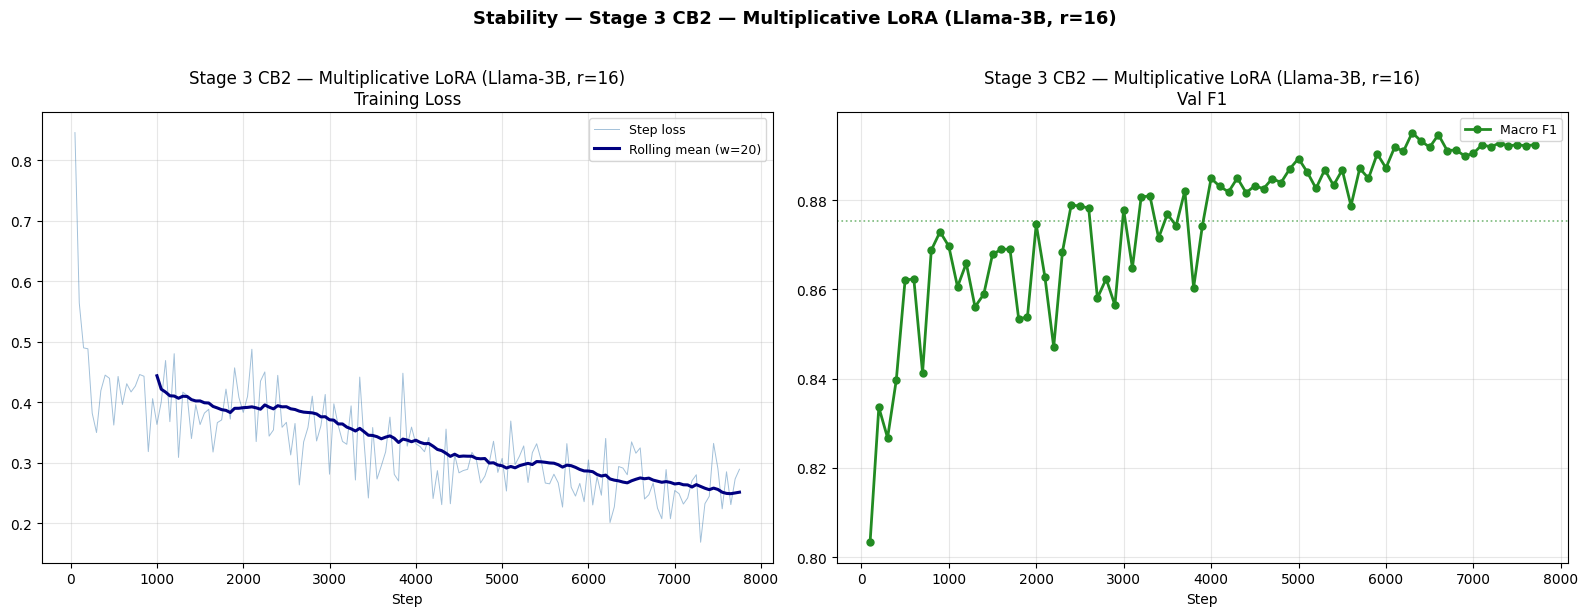

[8] Inference on test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — MultiplicativeLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9048
  Macro F1          : 0.8916  ← PRIMARY METRIC
  Balanced Accuracy : 0.8982
  MCC               : 0.7841  ← SECONDARY METRIC
  AUC-ROC           : 0.9643  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8538  (minority class)

                   precision    recall  f1-score   support

not_cyberbullying     0.9431    0.9163    0.9295     13923
    cyberbullying     0.8290    0.8801    0.8538      6423

         accuracy                         0.9048     20346
        macro avg     0.8860    0.8982    0.8916     20346
     weighted avg     0.9071    0.9048    0.9056     20346



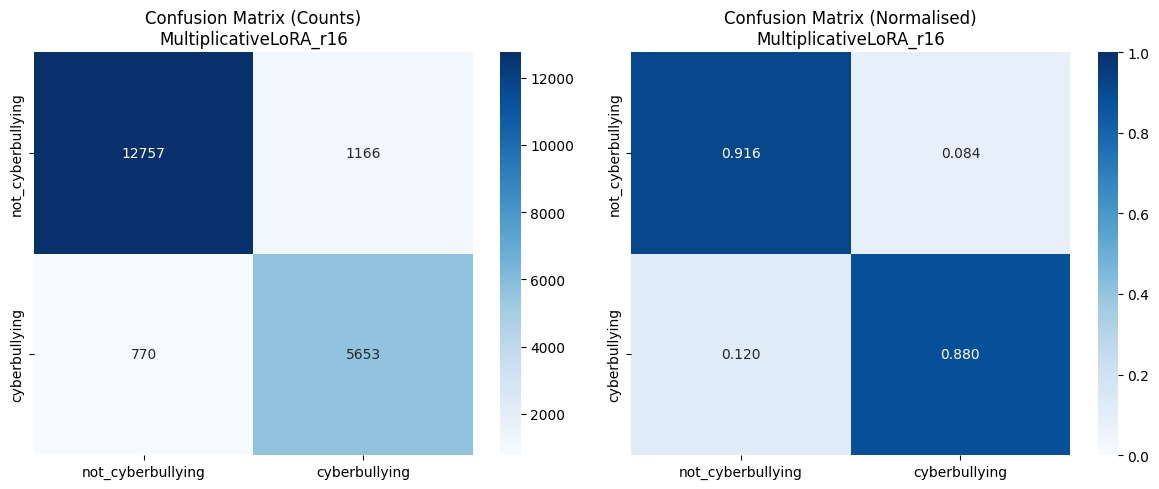


✓ Saved → /content/drive/MyDrive/Results/CB2_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r16/results_MultiplicativeLoRA_r16.csv

═════════════════════════════════════════════════════════════════
  STAGE 3 CB2 COMPLETE — Multiplicative LoRA (r=16)
  Formula : Wf = W(I + UV)   [Step 12 Only]
  Model   : meta-llama/Llama-3.2-3B-Instruct
═════════════════════════════════════════════════════════════════
  Macro F1          : 0.8916   ← PRIMARY METRIC
  MCC               : 0.7841
  AUC-ROC           : 0.9643
  F1 cyberbullying  : 0.8538   (minority class)
  Eff. rank Wf      : 2029.08
  Stability score   : 0.134428
  Training time     : 16490s  (4.58 hrs)
═════════════════════════════════════════════════════════════════

  Stage 2 CB2 reference (r=16):
  Llama-3B Stage 2 : F1=0.8885 | MCC=0.7800 | AUC=0.9650
  Stage 2 best CB2 : Mistral-7B F1=0.8888 | AUC=0.9664


In [11]:
results = run_multiplicative_lora_cb2(train_df, val_df, test_df)

print('\n' + '═'*65)
print('  STAGE 3 CB2 COMPLETE — Multiplicative LoRA (r=16)')
print('  Formula : Wf = W(I + UV)   [Step 12 Only]')
print(f'  Model   : {MODEL_NAME}')
print('═'*65)
print(f'  Macro F1          : {results["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC               : {results["mcc"]:.4f}')
print(f'  AUC-ROC           : {results["auc_roc"]:.4f}')
print(f'  F1 cyberbullying  : {results["f1_cyberbullying"]:.4f}   (minority class)')
print(f'  Eff. rank Wf      : {results["avg_eff_rank_Wf"]:.2f}')
print(f'  Stability score   : {results["stability_score"]}')
rt = results.get("train_runtime_s",0)
print(f'  Training time     : {rt:.0f}s  ({rt/3600:.2f} hrs)')
print('═'*65)
print()
print('  Stage 2 CB2 reference (r=16):')
print('  Llama-3B Stage 2 : F1=0.8885 | MCC=0.7800 | AUC=0.9650')
print('  Stage 2 best CB2 : Mistral-7B F1=0.8888 | AUC=0.9664')